<a href="https://colab.research.google.com/github/GabrielDaviBrito/AnaliseMultivariada-2026.2/blob/main/AnaliseMultivariadaCOLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
# '''from google.colab import userdata
#token = userdata.get("GITHUB_TOKEN")
#!git clone https://{token}@github.com/GabrielDaviBrito/AnaliseMultivariada-2026.2'''

# Processamento e tratamento dos dados

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import amvlib as amv
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# leitura dos dados no google colab
#df = pd.read_csv('/content/AnaliseMultivariada-2026.2/DADOS_INEP_ANALISE_MULTIVARIADA_SIGLAS.csv', sep=",")

# leitura dos dados no vscode (personalizar diretórios locais)
df = pd.read_csv('DADOS_INEP_ANALISE_MULTIVARIADA_SIGLAS.csv', sep=",")

df.head()

,Código da Instituição,Nome da Instituição,Categoria Administrativa,Organização Acadêmica,Código do Curso de Graduação,Nome do Curso de Graduação,Código da Região Geográfica do Curso,Código da Unidade Federativa do Curso,Código do Município do Curso,Grau Acadêmico,...,Quantidade de Ingressantes no Curso,Quantidade de Permanência no Curso no ano de referência,Quantidade de Concluintes no Curso no ano de referência,Quantidade de Desistência no Curso no ano de referência,Quantidade de Falecimentos no Curso no ano de referência,Taxa de Permanência - TAP,Taxa de Conclusão Acumulada - TCA,Taxa de Desistência Acumulada - TDA,Taxa de Conclusão Anual - TCAN,Taxa de Desistência Anual - TADA
0,1,UFMT,1,1,117004,PSICOLOGIA,5,51,5103403,1,...,89,52,26,1,0,"58,4","30,3","11,2","29,2","1,1"
1,2,UnB,1,1,22844,PSICOLOGIA,5,53,5300108,1,...,32,0,0,0,0,"0,0","59,4","40,6","0,0","0,0"
2,2,UnB,1,1,26033,PSICOLOGIA - PSICÓLOGO,5,53,5300108,1,...,123,62,21,1,0,"50,4","22,8","26,8","17,1","0,8"
3,2,UnB,1,1,44376,PSICOLOGIA,5,53,5300108,2,...,30,0,1,0,0,"0,0","46,7","53,3","3,3","0,0"
4,3,UFS,1,1,52852,PSICOLOGIA,2,28,2806701,1,...,46,13,18,1,0,"28,3","39,1","32,6","39,1","2,2"


In [79]:
# Definindo as colunas de interesse
variaveis_de_interesse = [
    'Código da Instituição', 'Nome da Instituição','Taxa de Permanência - TAP', 'Taxa de Conclusão Acumulada - TCA',
    'Taxa de Desistência Acumulada - TDA', 'Taxa de Conclusão Anual - TCAN',
    'Taxa de Desistência Anual - TADA'
]

# Filtrando/renomeando as colunas interessadas
df_filtrado = df[variaveis_de_interesse].copy()
df_filtrado = df_filtrado.rename(
    columns = {
        'Código da Instituição':'CO_IES',
        'Nome da Instituição':'NO_IES',
        'Taxa de Permanência - TAP':'TAP',
        'Taxa de Conclusão Acumulada - TCA':'TCA',
        'Taxa de Desistência Acumulada - TDA':'TDA',
        'Taxa de Conclusão Anual - TCAN':'TCAN',
        'Taxa de Desistência Anual - TADA':'TADA'
    }
)

# Filtrando colunas de taxa para float
indicadores_de_trajetoria = ['TAP','TCA','TDA','TCAN','TADA']
for taxa in indicadores_de_trajetoria:
  df_filtrado[taxa] = df_filtrado[taxa].str.replace(',','.').astype(float)
# Verificando filtragem dos dados
df_filtrado.head()

,CO_IES,NO_IES,TAP,TCA,TDA,TCAN,TADA
0,1,UFMT,58.4,30.3,11.2,29.2,1.1
1,2,UnB,0.0,59.4,40.6,0.0,0.0
2,2,UnB,50.4,22.8,26.8,17.1,0.8
3,2,UnB,0.0,46.7,53.3,3.3,0.0
4,3,UFS,28.3,39.1,32.6,39.1,2.2


# Gráfico de distribuições par a par

<Figure size 1000x600 with 0 Axes>

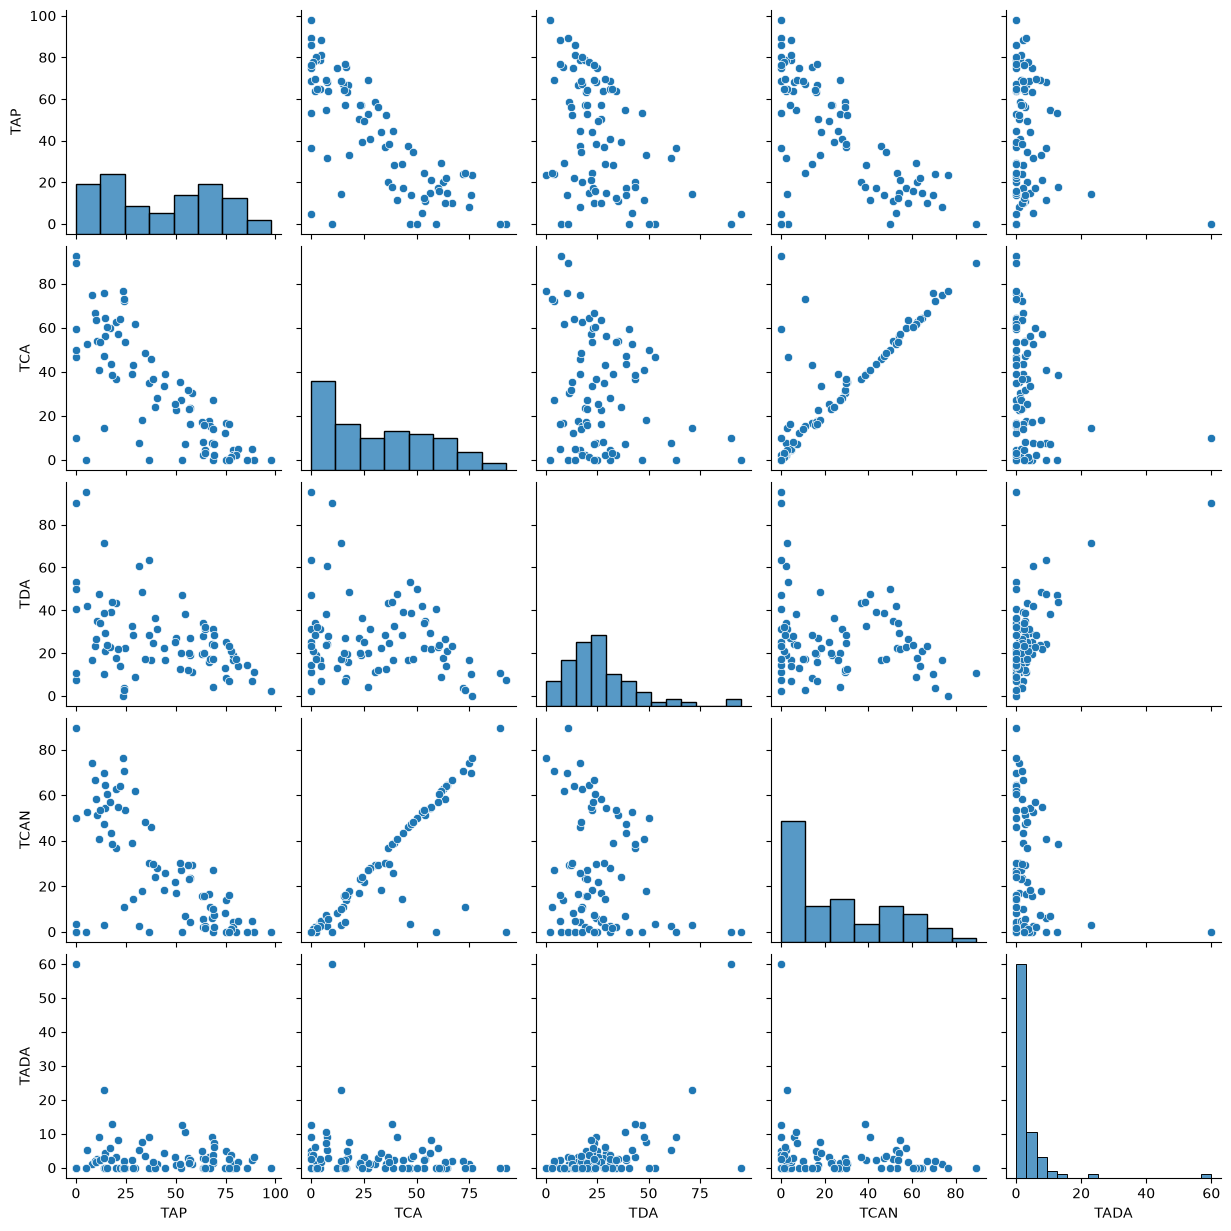

In [80]:
plt.figure(figsize=(10, 6))
grafico_pairwise = sns.pairplot(
    df_filtrado[indicadores_de_trajetoria],
    kind="scatter",
    markers=["o","s","D"],
    palette="Set2"
)
plt.show()

warnings.filterwarnings("ignore")

# Correlograma das variáveis

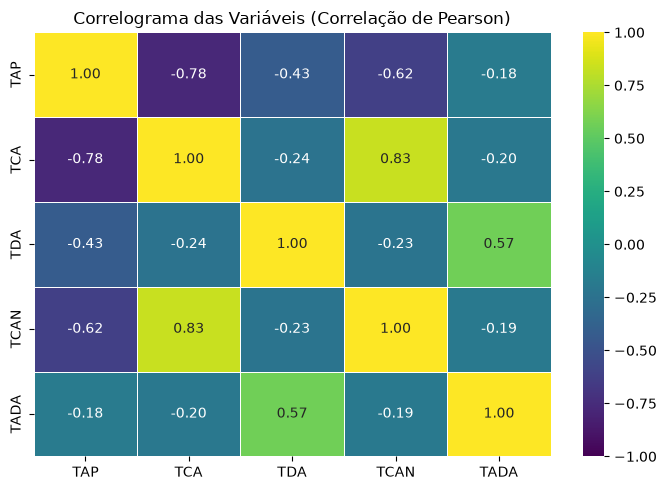

In [81]:
dados_pca = df_filtrado[indicadores_de_trajetoria].iloc[:,range(5)]

#Correlação de Pearson
corr_pearson = dados_pca.corr(method="pearson")

# Gráfico: Correlograma (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_pearson, annot=True, cmap='viridis', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

plt.title('Correlograma das Variáveis (Correlação de Pearson)')
plt.tight_layout()
plt.show()

# Variância explicada dos componentes sobre a matriz de correlações

In [82]:
# Padronização dos dados
scaler = StandardScaler()
X_std = scaler.fit_transform(dados_pca)
#Aplicação do PCA sobre a matriz de correlação
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Variância explicada
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

# Resumo numérico
tabela_var = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(var_explicada))],
    'Variância (%)': np.round(var_explicada, 2),
    'Acumulada (%)': np.round(var_acumulada, 2)
})
print("--- Variância Explicada ---")
print(tabela_var.to_string(index=False))

print("\n" + "="*50 + "\n")

tabela_loadings = pd.DataFrame(
    pca.components_.T,
    index=[indicadores_de_trajetoria],
    columns=[f'CP{i+1}' for i in range(len(pca.components_))]
)

print("--- Cargas Fatoriais (Pesos de cada variável nos Componentes) ---")
print(tabela_loadings.round(4))

--- Variância Explicada ---
Componente  Variância (%)  Acumulada (%)
       CP1          50.22          50.22
       CP2          35.89          86.11
       CP3           9.85          95.96
       CP4           4.04         100.00
       CP5           0.00         100.00


--- Cargas Fatoriais (Pesos de cada variável nos Componentes) ---
         CP1     CP2     CP3     CP4     CP5
TAP  -0.5153 -0.3996  0.2552  0.2679  0.6617
TCA   0.6136 -0.0451  0.0826 -0.4856  0.6155
TDA  -0.0858  0.6824 -0.5129  0.2837  0.4283
TCAN  0.5787 -0.0758  0.2328  0.7779  0.0001
TADA -0.1253  0.6057  0.7815 -0.0817 -0.0001


# Variância explicada dos componentes sobre a matriz de covariâncias

In [83]:
#Aplicação do PCA sobre a matriz de covariancia
pca = PCA()
pca.fit_transform(dados_pca)

# Variância explicada
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

# Resumo numérico
tabela_var = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(var_explicada))],
    'Variância (%)': np.round(var_explicada, 2),
    'Acumulada (%)': np.round(var_acumulada, 2)
})
print("--- Variância Explicada ---")
print(tabela_var.to_string(index=False))

print("\n" + "="*50 + "\n")

tabela_loadings = pd.DataFrame(
    pca.components_.T,
    index=[indicadores_de_trajetoria],
    columns=[f'CP{i+1}' for i in range(len(pca.components_))]
)

print("--- Cargas Fatoriais (Pesos de cada variável nos Componentes) ---")
print(tabela_loadings.round(4))

--- Variância Explicada ---
Componente  Variância (%)  Acumulada (%)
       CP1          70.03          70.03
       CP2          23.37          93.40
       CP3           5.14          98.54
       CP4           1.46         100.00
       CP5           0.00         100.00


--- Cargas Fatoriais (Pesos de cada variável nos Componentes) ---
         CP1     CP2     CP3     CP4     CP5
TAP   0.6015 -0.5118  0.1963  0.0670  0.5773
TCA  -0.5963 -0.2266 -0.4983  0.1071  0.5773
TDA  -0.0051  0.7384  0.3018 -0.1738  0.5774
TCAN -0.5315 -0.3279  0.7807 -0.0215  0.0001
TADA  0.0115  0.1842  0.1121  0.9764 -0.0002


# Gráfico de dispersão das observações do PCA

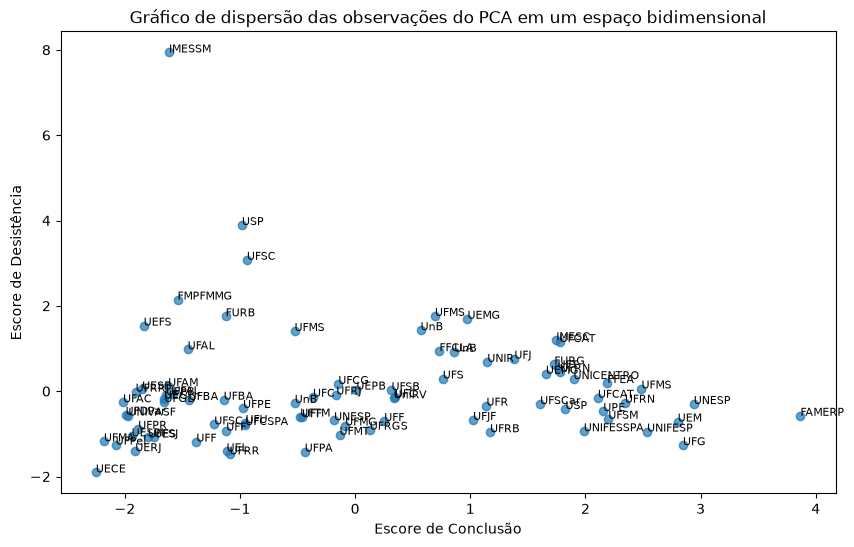

In [84]:
# Retomando aos componentes sobre a matriz de correlação
X_pca = pca.fit_transform(X_std)
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = np.cumsum(var_explicada)

# Criar um gráfico de dispersão para visualizar as observações em um plano cartesiano  
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0],            # posição do primeiro componente principal 
            X_pca[:, 1], alpha=0.7) # posição do segundo componente principal

# Adicionar título e rótulo dos eixos 
plt.title('Gráfico de dispersão das observações do PCA em um espaço bidimensional')
plt.xlabel('Escore de Conclusão')
plt.ylabel('Escore de Desistência')

# Adicionar rótulo de cada ponto baseado no rótulo das observações 
for i, txt in enumerate(df_filtrado.iloc[:,1]):
    plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]), fontsize=8)

# Mostrar gráfico
plt.show()

# Biplot (PCA sobre a matriz de correlação)

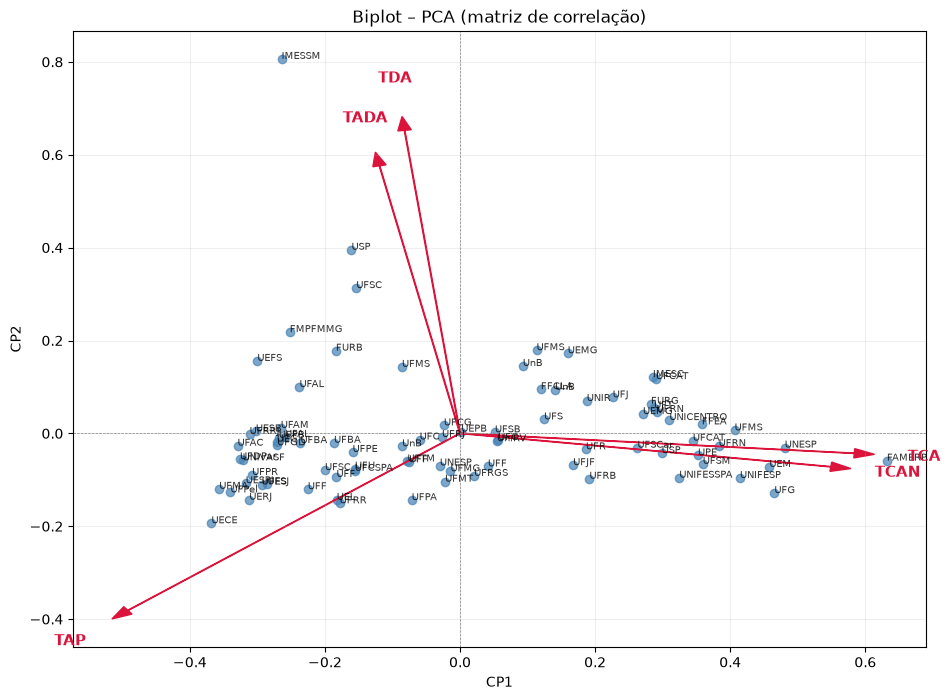

In [86]:
fig, ax = plt.subplots(figsize=(11, 8))
amv.biplot(X_pca, pca.components_.T, df_filtrado['NO_IES'], indicadores_de_trajetoria, pc=(0, 1), ax=ax)
plt.show()